# 선형회귀

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# 단순선형회귀 모델 만들기

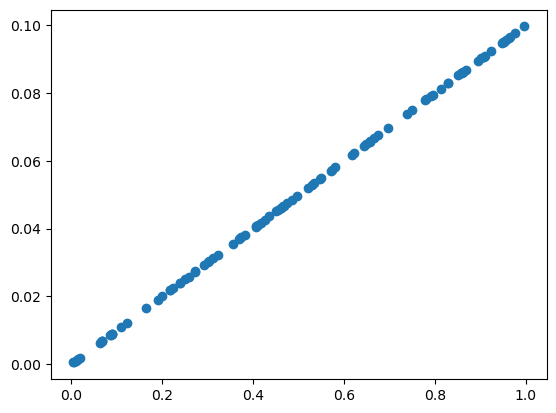

In [3]:
X = np.random.rand(100)
y = 0.2 * X * 0.5   # ax + b

plt.scatter(X,y)

In [4]:
def plt_prediction(pred, y):
    plt.figure(figsize=(8,6))
    plt.scatter(X, y, color='blue', label='Actual')   # 실제값
    plt.scatter(X, pred, color='orange', label='Prediction')   # 예측값
    plt.legend()
    plt.show()

# 경사하강법 y = wX+b, w 결정

In [5]:
w = np.random.uniform(-1, 1)   #임의의 값
b = np.random.uniform(-1, 1)   #임의의 값

learning_rate = 0.5   #임의의 값

Epoch 0, w : -0.2509, Error : 0.2132


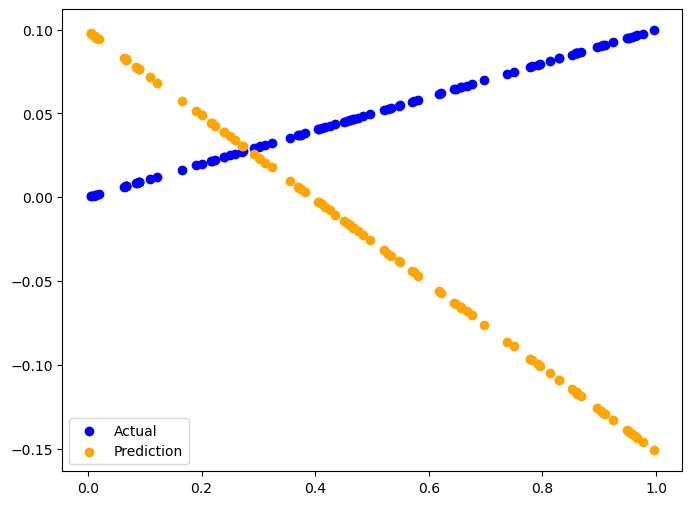

Epoch 10, w : -0.1187, Error : 0.0593


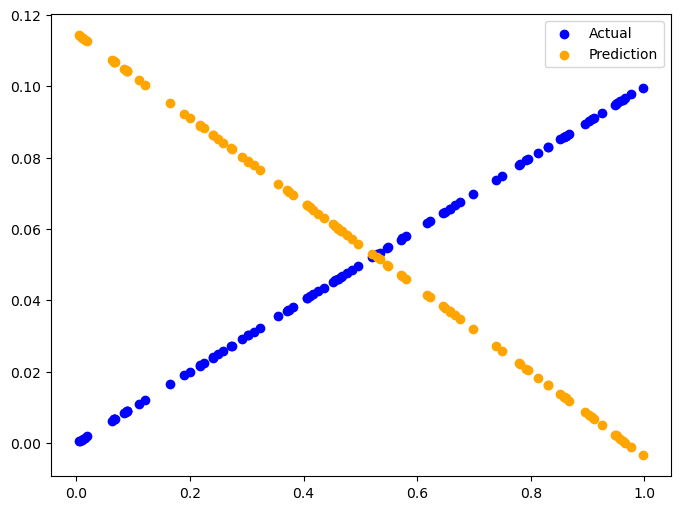

Epoch 20, w : -0.0514, Error : 0.0411


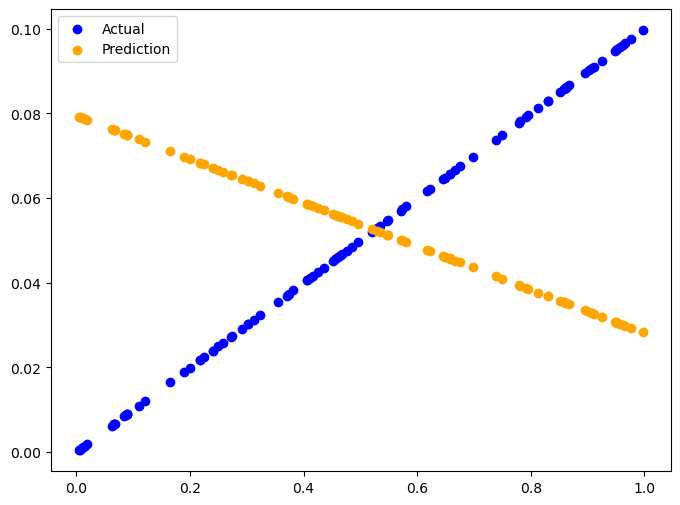

Epoch 30, w : -0.0049, Error : 0.0284


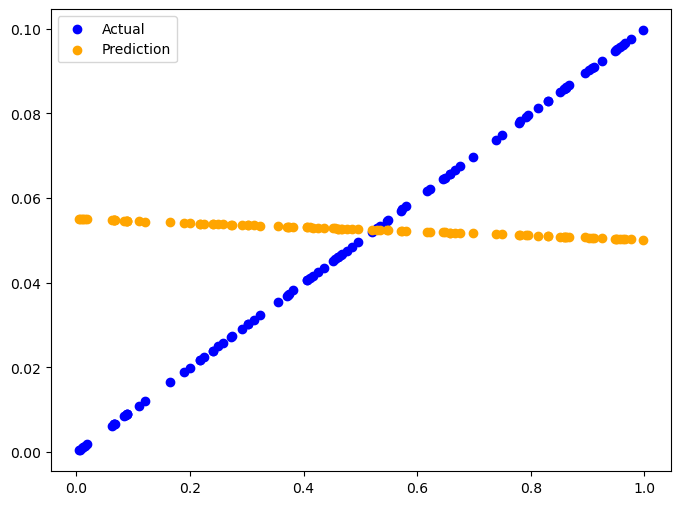

Epoch 40, w : 0.0274, Error : 0.0197


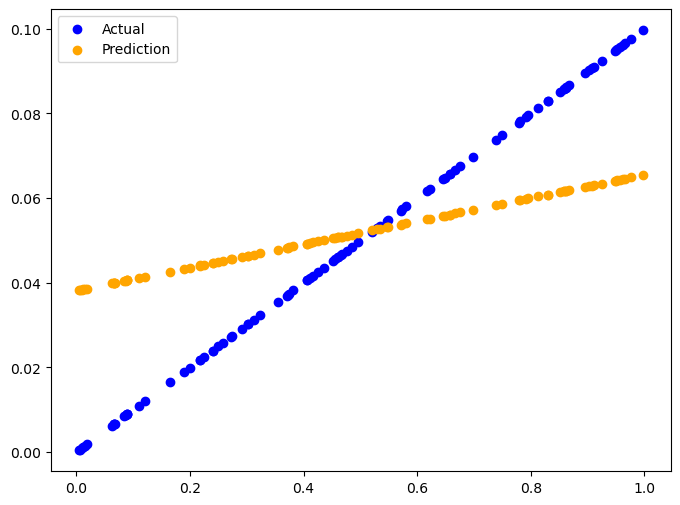

Epoch 50, w : 0.0497, Error : 0.0136


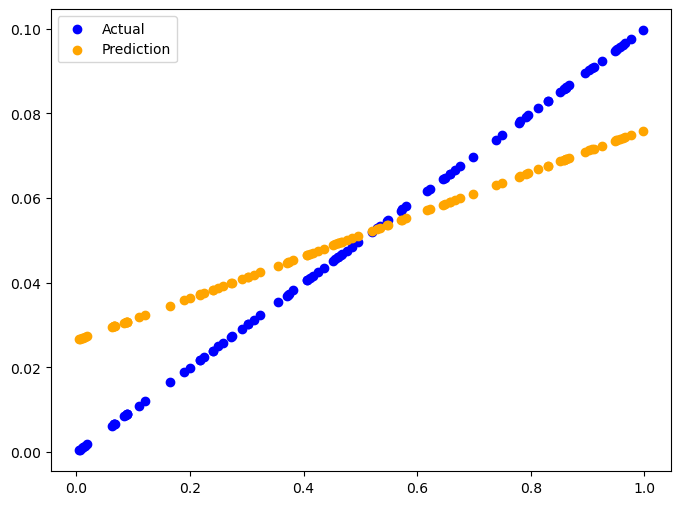

Epoch 60, w : 0.0652, Error : 0.0094


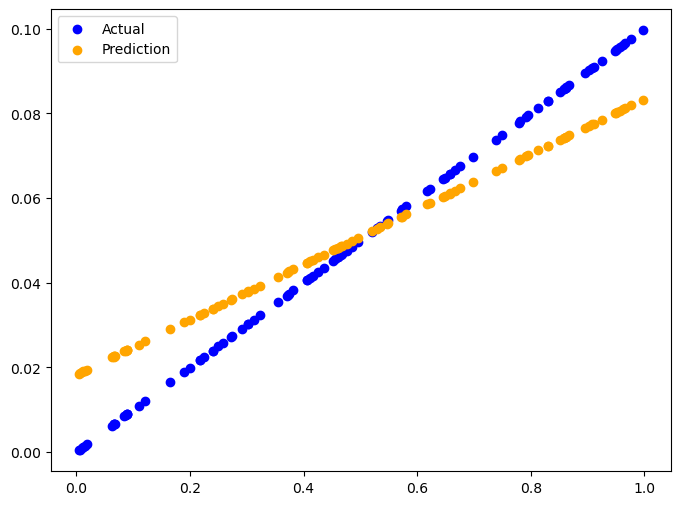

Epoch 70, w : 0.0759, Error : 0.0065


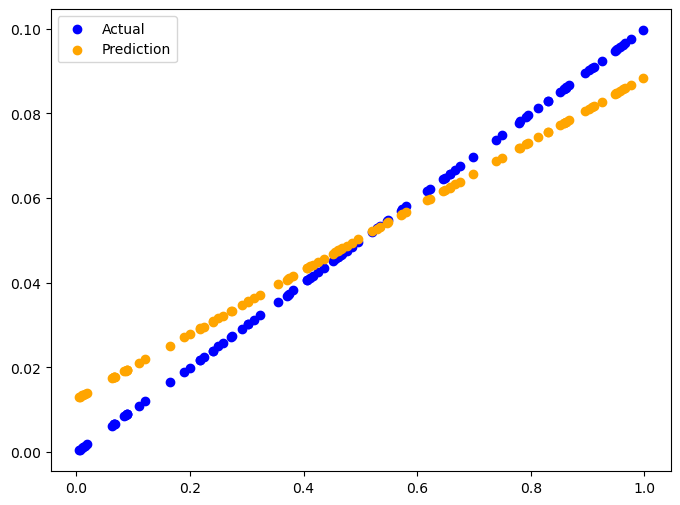

Epoch 80, w : 0.0833, Error : 0.0045


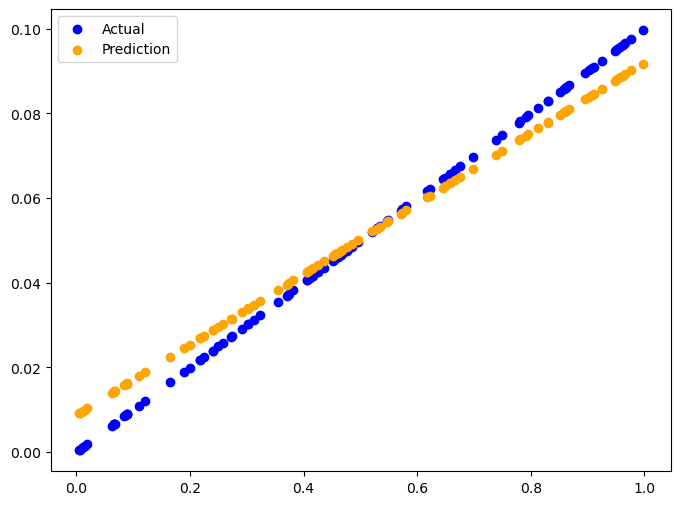

Epoch 90, w : 0.0884, Error : 0.0031


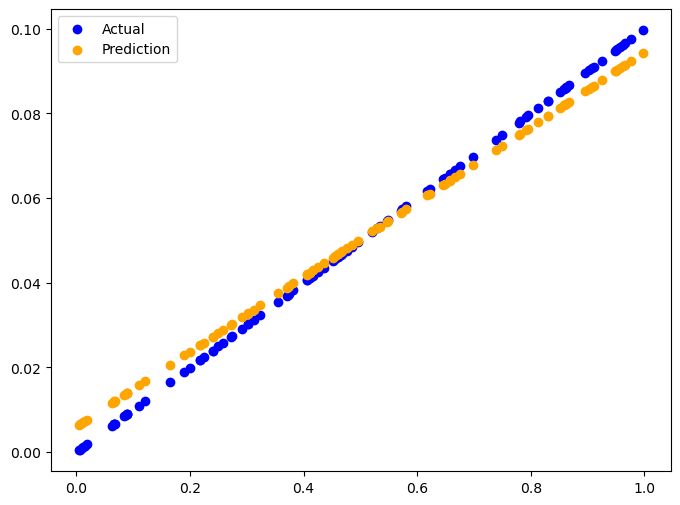

In [6]:
for epoch in range(100):
    y_pred = w * X + b
    error = np.abs(y_pred - y).mean()   # 손실함수
    if error < 0.001:
        break
    w_descent = learning_rate * ((y_pred - y) * X).mean()
    b_descent = learning_rate * ((y_pred - y).mean())
    w = w - w_descent
    b = b - b_descent
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, w : {w:.4f}, Error : {error:.4f}')
        y_pred = w * X + b
        plt_prediction(y_pred, y)

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

In [8]:
bostonDF = pd.read_csv('./data/boston.csv')
bostonDF.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'target'],
      dtype='object')

In [9]:
bostonDF.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,target
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [10]:
X = bostonDF.drop('target', axis=1).values
y = bostonDF['target'].values
bostonDF.shape

(506, 14)

# 모델 만들기 (보스턴 집값)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=156)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
y_pred[:3]

array([23.15424087, 19.65590246, 36.42005168])

In [12]:
# 평가
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
rmse, mse

(np.float64(4.158956107955705), np.float64(17.296915907902065))

In [13]:
# 결정계수
r2_score(y_test, y_pred)

np.float64(0.7572263323138934)

In [14]:
# 회귀식
# w0, w1
lr.intercept_, lr.coef_

(np.float64(40.99559517216439),
 array([-1.12979614e-01,  6.55124002e-02,  3.44366694e-02,  3.04589777e+00,
        -1.97958320e+01,  3.35496880e+00,  5.93713290e-03, -1.74185354e+00,
         3.55884364e-01, -1.42954516e-02, -9.20180066e-01,  1.03966156e-02,
        -5.66182106e-01]))

y = w0 + w1*X1 + w2*X2 + ... + w13*X13 이므로 w가 13개 나온다

In [15]:
np.round(lr.intercept_, 1), np.round(lr.coef_, 1)

(np.float64(41.0),
 array([ -0.1,   0.1,   0. ,   3. , -19.8,   3.4,   0. ,  -1.7,   0.4,
         -0. ,  -0.9,   0. ,  -0.6]))

In [16]:
pd.Series(data=np.round(lr.coef_, 1), index=bostonDF.drop('target', axis=1).columns).sort_values(ascending=False)

RM          3.4
CHAS        3.0
RAD         0.4
ZN          0.1
INDUS       0.0
B           0.0
TAX        -0.0
AGE         0.0
CRIM       -0.1
LSTAT      -0.6
PTRATIO    -0.9
DIS        -1.7
NOX       -19.8
dtype: float64

In [18]:
from sklearn.model_selection import cross_val_score
neg_mse_score = cross_val_score(lr, X, y, scoring='neg_mean_squared_error', cv=5)
neg_mse_score

array([-12.46030057, -26.04862111, -33.07413798, -80.76237112,
       -33.31360656])

In [20]:
# MSE, RMSE
RMSE = np.sqrt(neg_mse_score * -1)
np.mean(RMSE), RMSE

(np.float64(5.828658946215813),
 array([3.52991509, 5.10378498, 5.75101191, 8.9867887 , 5.77179405]))

In [21]:
# R2
r2_scores = cross_val_score(lr, X, y, scoring='r2', cv=5)
r2_scores, np.mean(r2_scores)

(array([ 0.63919994,  0.71386698,  0.58702344,  0.07923081, -0.25294154]),
 np.float64(0.3532759243958839))

오차는 커지고(4.15 -> 5.85), 결정계수는 작아진(0.75 -> 0.35) 결과

# 다항회귀모델
y = w0 + w1 * x1 + w2 * x2 + x3 * x1^2 + w4 * x2^2

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=156)
model_poly = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('linear', LinearRegression())]
)
model_poly.fit(X_train, y_train)

Pipeline(steps=[('poly', PolynomialFeatures(include_bias=False)),
                ('linear', LinearRegression())])

In [27]:
pred_poly = model_poly.predict(X_test)
mean_squared_error(y_test, pred_poly)

np.float64(15.555752307472005)

In [28]:
r2_score(y_test, pred_poly)

np.float64(0.7816647163338353)

#### 2차~5차 다항회귀 시뮬레이션 (LineareRegressor)

In [32]:
results = []

for degree in range(1,5):
    model_poly = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('linear', LinearRegression())]
    )
    model_poly.fit(X_train, y_train)
    pred_poly = model_poly.predict(X_test)
    mse = mean_squared_error(y_test, pred_poly)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred_poly)
    results.append({'degree':degree, 'MSE':mse, 'RMSE':rmse, 'R2':r2})
    
pd.DataFrame(results)

,degree,MSE,RMSE,R2
0,1,17.296916,4.158956,0.757226
1,2,15.555752,3.944078,0.781665
2,3,79625.592348,282.180071,-1116.597912
3,4,170599.948638,413.037466,-2393.483240


+ 결과를보니 R2스코어가 3차에서 갑자기 마이너스로 값이 뚝 떨어져서 이 모델은 3차까지 갈 필요가 없다

#### 2차~5차 다항회귀 시뮬레이션 (RandomForest)

In [33]:
from sklearn.ensemble import RandomForestRegressor

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=156)
model_poly = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('RandomForest', RandomForestRegressor())]
)
model_poly.fit(X_train, y_train)

Pipeline(steps=[('poly', PolynomialFeatures(include_bias=False)),
                ('RandomForest', RandomForestRegressor())])

In [35]:
pred_poly = model_poly.predict(X_test)
mean_squared_error(y_test, pred_poly)

np.float64(7.598798355263157)

In [36]:
r2_score(y_test, pred_poly)

np.float64(0.8933458336424239)

In [38]:
results = []

for degree in range(1,6):
    model_poly = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('RandomForest', RandomForestRegressor())]
    )
    model_poly.fit(X_train, y_train)
    pred_poly = model_poly.predict(X_test)
    mse = mean_squared_error(y_test, pred_poly)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred_poly)
    results.append({'degree':degree, 'MSE':mse, 'RMSE':rmse, 'R2':r2})
    
pd.DataFrame(results)

,degree,MSE,RMSE,R2
0,1,7.558959,2.749356,0.893905
1,2,7.501697,2.738923,0.894709
2,3,7.179497,2.679458,0.899231
3,4,7.278030,2.697782,0.897848
4,5,7.404124,2.721052,0.896078
